In [26]:
import pandas as pd
import numpy as np

import statistics
import scipy.stats as stats
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.proportion import proportions_ztest

In [2]:
df = pd.read_csv('test_ex.csv')
df.head()

,date,user_id,view_adverts
0,2023-11-11,8c020470-8461-11ed-83d0-552e8cc749d6,13
1,2023-11-18,5875f070-7b92-11ee-a6fb-8b298e83f4f7,14
2,2023-11-29,3c2d27c0-4fd6-11eb-b89f-2ffb31b67dd6,21
3,2023-11-29,234a96d0-ad16-11ed-a2e6-793ddfeeba1f,23
4,2023-11-29,4d07c180-644f-11eb-879c-b7c02edf4f37,12


In [3]:
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16814 entries, 0 to 16813
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          16814 non-null  datetime64[ns]
 1   user_id       16814 non-null  object        
 2   view_adverts  16814 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 394.2+ KB


### 1

In [50]:
mau = df['user_id'].unique()
len(mau)

7639

### 2

In [35]:
dau = df.groupby('date')['user_id'].nunique()
print(dau.mean())

560.4666666666667


### 3

In [41]:
nov1 = df.loc[df['date'] == '2023-11-01', 'user_id'].unique()
nov2 = df.loc[df['date'] == '2023-11-02', 'user_id'].unique()
retained = pd.Series(nov1).isin(nov2).sum()
print(f'Retention первого дня: {retained * 100 / len(nov1)}')

Retention D1: 26.64526484751204


### 4

Продукт который описывается красным, говорит что вся группа которая подключилась в n день полностью перестала пользоваться продуктом на 5-ый день. У второго продукта 40 % пользователей с n-го дня остались и повторно пользуются продуктом каждый день.

### 5

In [49]:
once_views = df.loc[df['view_adverts'] != 0, 'user_id'].unique()
all_user = df['user_id'].unique()
print(f'Конверсия: {len(once_views) * 100 / len(all_user)}')

Конверсия: 46.31496269145176


### 6

In [53]:
print(df['view_adverts'].sum()/len(all_user))

2.8687000916350307


### 7

Критики % = 500 / 2000 = 25%
Сторонники % = 1200 / 2000 = 60%
NPS = 60 - 25 = 35%

### 8

In [3]:
df_AB = pd.read_csv('test_ex_AB.csv')
df_AB.head()

,experiment_num,experiment_group,user_id,revenue
0,1,test,38456,520
1,1,control,13125924,806
2,1,control,9761984,0
3,1,test,11387012,208
4,1,test,18319648,104


In [4]:
df_AB.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2835 entries, 0 to 2834
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   experiment_num    2835 non-null   int64 
 1   experiment_group  2835 non-null   object
 2   user_id           2835 non-null   int64 
 3   revenue           2835 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 88.7+ KB


In [5]:
AB_exp_1_test = df_AB[(df_AB['experiment_num'] == 1) & (df_AB['experiment_group'] == 'test')]
AB_exp_1_test_rev = AB_exp_1_test['revenue'].tolist()
AB_exp_1_control = df_AB[(df_AB['experiment_num'] == 1) & (df_AB['experiment_group'] == 'control')]
AB_exp_1_control_rev = AB_exp_1_control['revenue'].tolist()

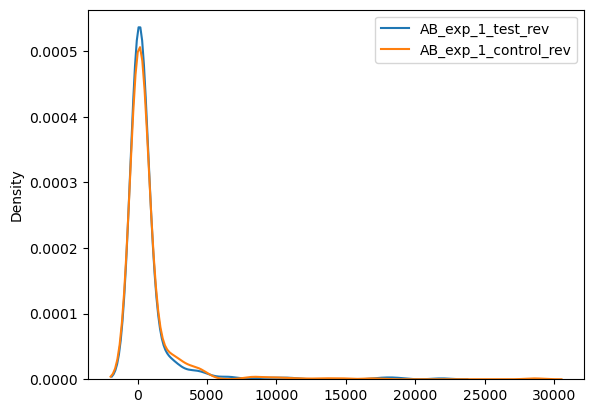

In [7]:
sns.kdeplot(AB_exp_1_test_rev, label='AB_exp_1_test_rev')
sns.kdeplot(AB_exp_1_control_rev, label='AB_exp_1_control_rev')
plt.legend()
plt.show()

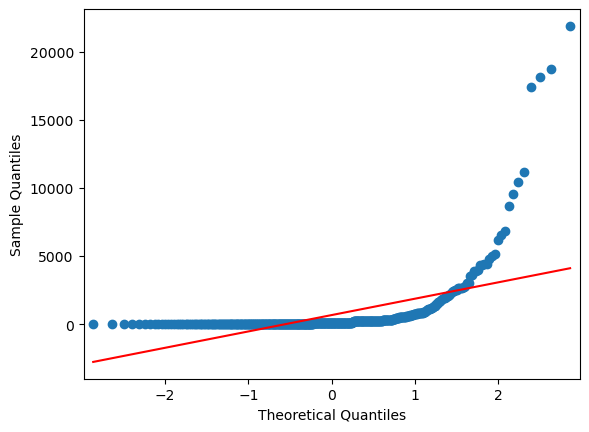

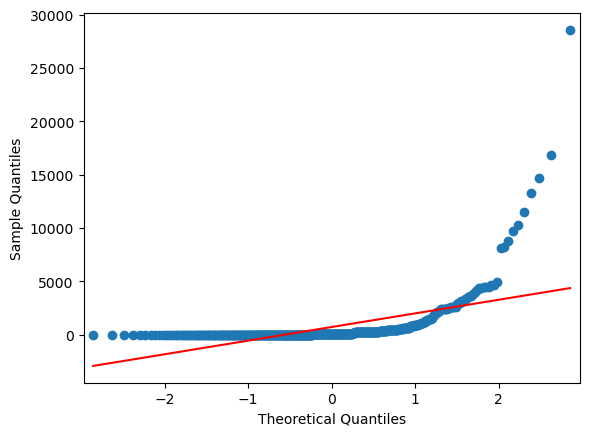

In [8]:
sm.qqplot(np.array(AB_exp_1_test_rev), line='r')
sm.qqplot(np.array(AB_exp_1_control_rev), line='r')
plt.show()

In [10]:
t_statistic, p_value = stats.ttest_ind(AB_exp_1_test_rev, AB_exp_1_control_rev)

print(f"t-статистика: {t_statistic}")
print(f"P-значение: {p_value}")

alpha = 0.05
if p_value < alpha:
    print('Различия в ARPU статистически значимы')
else:
    print('Статистически значимых различий в ARPU нет')

t-статистика: -0.4006287660577395
P-значение: 0.688784211779017
Статистически значимых различий в ARPU нет


В результатах первого АБ теста значимых различий в revenue между тестовой и контрольной группами не выявлено.

In [11]:
AB_exp_2_test = df_AB[(df_AB['experiment_num'] == 2) & (df_AB['experiment_group'] == 'test')]
AB_exp_2_test_rev = AB_exp_2_test['revenue'].tolist()
AB_exp_2_control = df_AB[(df_AB['experiment_num'] == 2) & (df_AB['experiment_group'] == 'control')]
AB_exp_2_control_rev = AB_exp_2_control['revenue'].tolist()

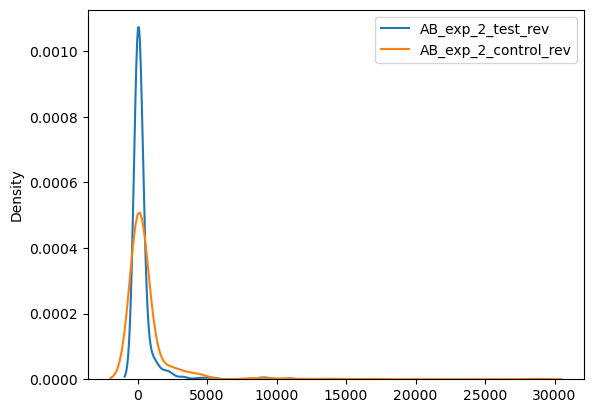

In [12]:
sns.kdeplot(AB_exp_2_test_rev, label='AB_exp_2_test_rev')
sns.kdeplot(AB_exp_2_control_rev, label='AB_exp_2_control_rev')
plt.legend()
plt.show()

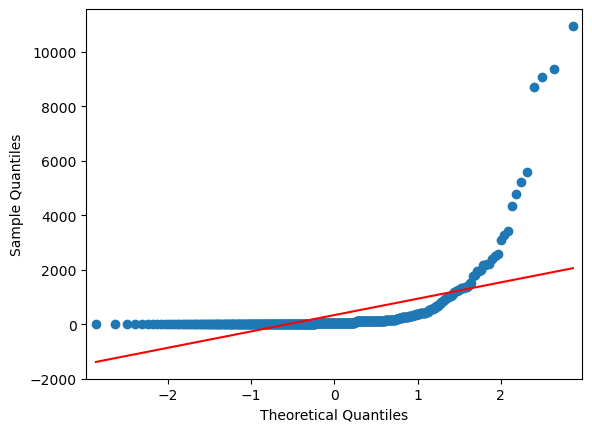

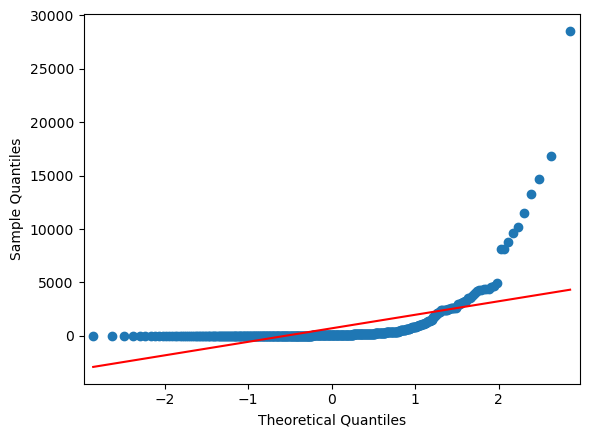

In [13]:
sm.qqplot(np.array(AB_exp_2_test_rev), line='r')
sm.qqplot(np.array(AB_exp_2_control_rev), line='r')
plt.show()

In [14]:
t_statistic, p_value = stats.ttest_ind(AB_exp_2_test_rev, AB_exp_2_control_rev)

print(f"t-статистика: {t_statistic}")
print(f"P-значение: {p_value}")

alpha = 0.05
if p_value < alpha:
    print('Различия в ARPU статистически значимы')
else:
    print('Статистически значимых различий в ARPU нет')

t-статистика: -3.303268516112734
P-значение: 0.0009915972237576193
Различия в ARPU статистически значимы


C:\Users\Админ\AppData\Local\Temp\ipykernel_12552\2317009030.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([AB_exp_2_control_rev, AB_exp_2_test_rev], labels=['Контроль', 'Тест'], showfliers=False)


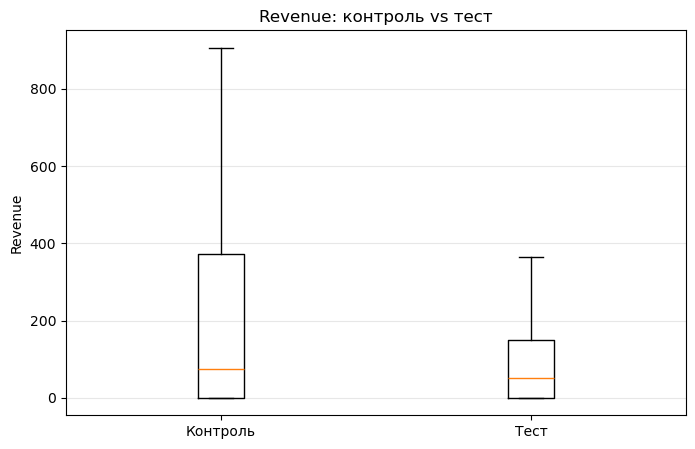

In [15]:
plt.figure(figsize=(8, 5))
plt.boxplot([AB_exp_2_control_rev, AB_exp_2_test_rev], labels=['Контроль', 'Тест'], showfliers=False)
plt.ylabel('Revenue')
plt.title('Revenue: контроль vs тест')
plt.grid(axis='y', alpha=0.3)
plt.show()

В результатах второго АБ теста различие в revenue между тестовой и контрольной статистически значимо. Результаты контрольной группы лучше, поэтому изменения не пошли на пользу.

In [21]:
AB_exp_3_test = df_AB[(df_AB['experiment_num'] == 3) & (df_AB['experiment_group'] == 'test')]
AB_exp_3_test_rev = AB_exp_3_test['revenue'].tolist()
AB_exp_3_control = df_AB[(df_AB['experiment_num'] == 3) & (df_AB['experiment_group'] == 'control')]
AB_exp_3_control_rev = AB_exp_3_control['revenue'].tolist()

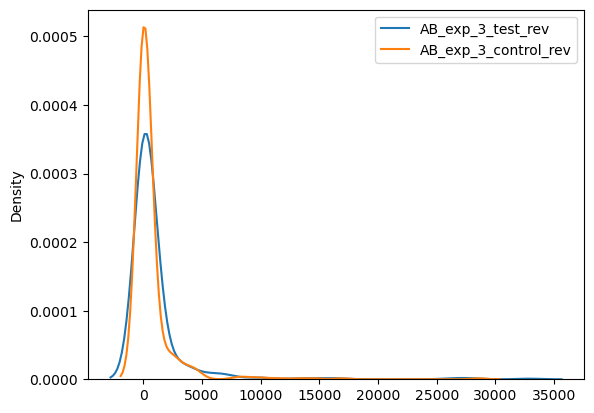

In [22]:
sns.kdeplot(AB_exp_3_test_rev, label='AB_exp_3_test_rev')
sns.kdeplot(AB_exp_3_control_rev, label='AB_exp_3_control_rev')
plt.legend()
plt.show()

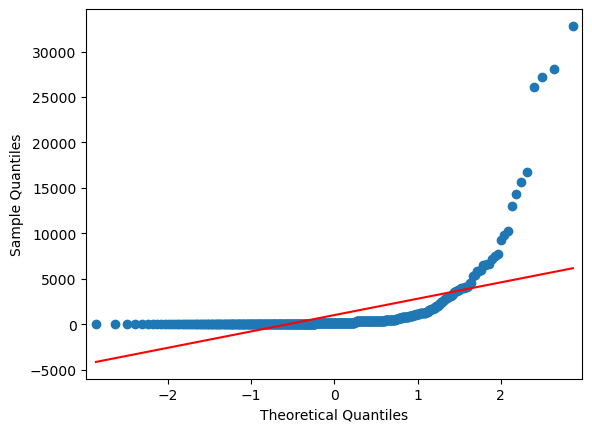

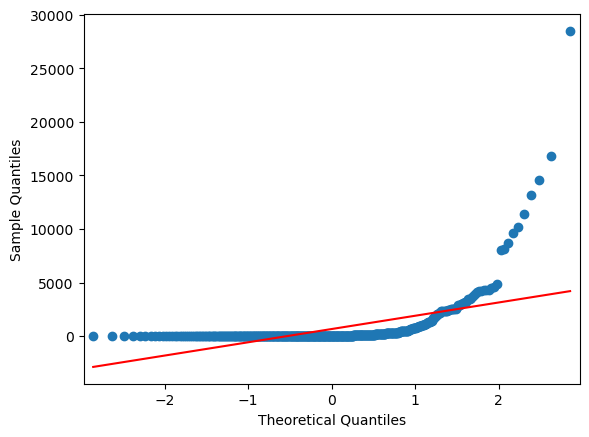

In [23]:
sm.qqplot(np.array(AB_exp_3_test_rev), line='r')
sm.qqplot(np.array(AB_exp_3_control_rev), line='r')
plt.show()

In [24]:
t_statistic, p_value = stats.ttest_ind(AB_exp_3_test_rev, AB_exp_3_control_rev)

print(f"t-статистика: {t_statistic}")
print(f"P-значение: {p_value}")

alpha = 0.05
if p_value < alpha:
    print('Различия в ARPU статистически значимы')
else:
    print('Статистически значимых различий в ARPU нет')

t-статистика: 1.8703638838987622
P-значение: 0.06174290011218765
Статистически значимых различий в ARPU нет


В результатах третьего АБ теста в revenue между тестовой и контрольной статистически значимых различий нет. У нас нет оснований утверждать, что изменение повлияло на среднюю выручку с пользователя.

### 9

In [29]:
lister = pd.read_csv('test_ex_lister.csv')
lister.head()

,user_id,date,cnt_adverts,age,cnt_contacts,revenue
0,100,2022-01-01,6,21,119,53
1,100,2022-01-02,2,21,200,18
2,100,2022-01-03,6,21,193,42
3,100,2022-01-04,2,21,143,38
4,100,2022-01-05,2,21,190,40


In [31]:
lister['date'] = pd.to_datetime(lister['date'])
lister.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       158 non-null    int64         
 1   date          158 non-null    datetime64[ns]
 2   cnt_adverts   158 non-null    int64         
 3   age           158 non-null    int64         
 4   cnt_contacts  158 non-null    int64         
 5   revenue       158 non-null    int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 7.5 KB


In [32]:
user_cnt = lister['user_id'].nunique()
sum_revenue = lister['revenue'].sum()

print(f'ARPU = {sum_revenue / user_cnt}')

ARPU = 156.48387096774192


### 10

In [34]:
print(f'Медиана возраста пользователей: {np.median(lister['age'])}')

Медиана возраста пользователей: 28.0


### 11

Гистограмма и Ящик с усами

### 12

№3

### 13

№3

### 14

Scatter Plot и Correlation Heatmap

### 15

Есть 5% вероятность случайно получить такой или еще более экстремальный результат, если нулевая гипотеза верна

### 16

t-тест

### 17

Делят данные на четыре равные части

### 18

In [29]:
payments = [1099, 1003]
visitors = [100_001_055, 100_047_501]

z_stat, p_value = proportions_ztest(payments, visitors)

print(f'Конверсия A: {1003 * 100 / 100_047_501}%')
print(f'Конверсия B: {1099 * 100 / 100_001_055}%')
print(f'z = {z_stat:.2f}, p-value = {p_value:.4f}')

Конверсия A: 0.0010025237911739544%
Конверсия B: 0.0010989884056723201%
z = 2.10, p-value = 0.0353


Различие статистически значимо: вариант B повышает конверсию в платёж. Результаты коллег подтверждаются.